In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving IMDb Movies India.csv.csv to IMDb Movies India.csv.csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving IMDb Movies India.csv.csv to IMDb Movies India.csv (1).csv


In [6]:
import pandas as pd

df = pd.read_csv("IMDb Movies India.csv (1).csv", encoding="latin1")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [7]:
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant 

In [8]:
# Remove rows where important values are missing
df = df.dropna(subset=['Year', 'Duration', 'Votes', 'Rating'])

# Remove duplicate movies
df = df.drop_duplicates(subset=['Name', 'Year', 'Director'])

# Convert Year to number
df['Year'] = df['Year'].str.replace('(', '', regex=False)
df['Year'] = df['Year'].str.replace(')', '', regex=False)
df['Year'] = pd.to_numeric(df['Year'])

# Convert Duration to number
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'])

# Convert Votes to number
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'])

print("Cleaning completed!")
print("New shape:", df.shape)
print(df.head())

Cleaning completed!
New shape: (5850, 10)
                                 Name  Year  Duration  \
1  #Gadhvi (He thought he was Gandhi)  2019       109   
3                             #Yaaram  2019       110   
5                ...Aur Pyaar Ho Gaya  1997       147   
6                           ...Yahaan  2005       142   
8                  ?: A Question Mark  2012        82   

                       Genre  Rating  Votes        Director          Actor 1  \
1                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
3            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
5     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
6        Drama, Romance, War     7.4   1086  Shoojit Sircar  Jimmy Sheirgill   
8  Horror, Mystery, Thriller     5.6    326   Allyson Patel        Yash Dave   

                  Actor 2          Actor 3  
1          Vivek Ghamande    Arvind Jangid  
3              Ishita Raj  Siddhant Kapoor  

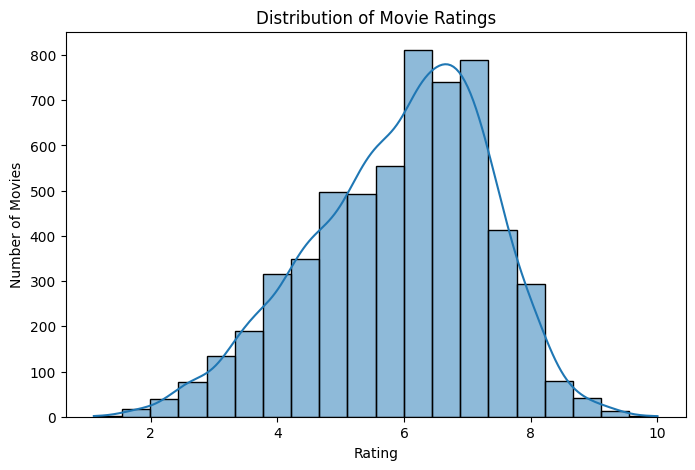

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Rating'], bins=20, kde=True)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')

plt.show()

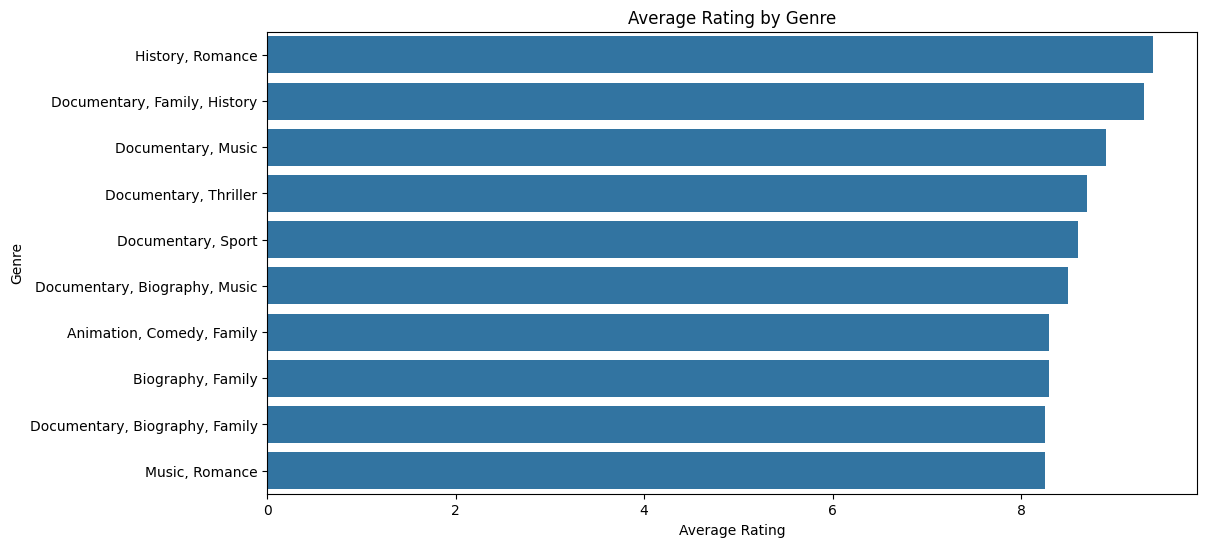

In [10]:
plt.figure(figsize=(12,6))

genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=genre_rating.values, y=genre_rating.index)

plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')

plt.show()

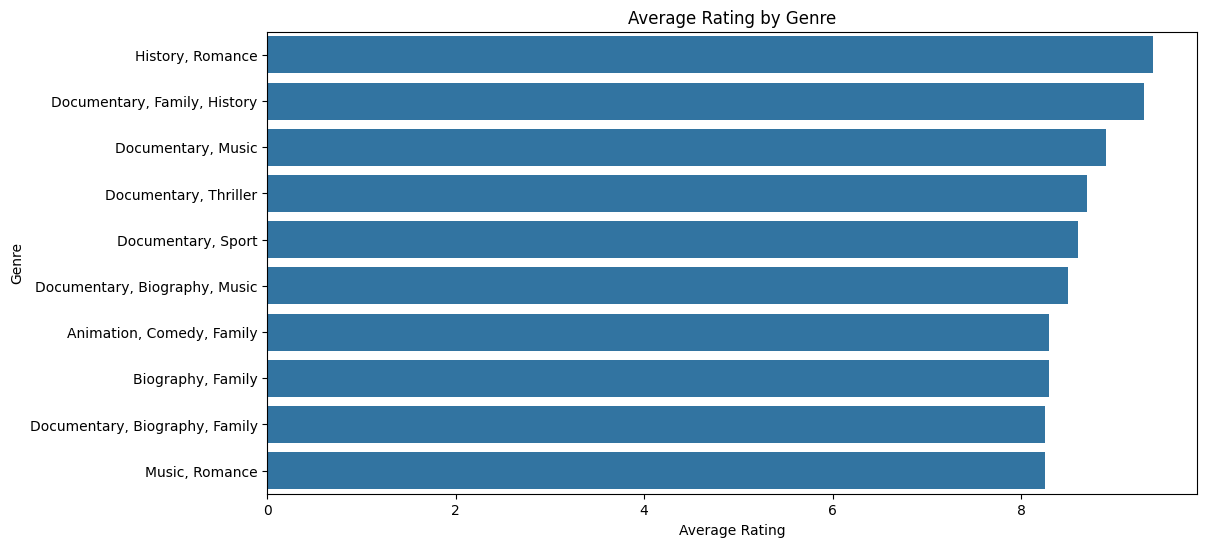

In [11]:
plt.figure(figsize=(12,6))

genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=genre_rating.values, y=genre_rating.index)

plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')

plt.show()

In [12]:
# Select input features
X = df[['Year', 'Duration', 'Votes']]

# Target variable
y = df['Rating']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
   Year  Duration  Votes
1  2019       109      8
3  2019       110     35
5  1997       147    827
6  2005       142   1086
8  2012        82    326

Target:
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64

Feature shape: (5850, 3)
Target shape: (5850,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4680, 3)
Testing data: (1170, 3)


In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions completed!

First 10 predictions:
[5.943  5.7675 5.62   5.264  7.056  5.107  5.307  5.657  5.363  5.232 ]


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation:
MAE  : 0.8979146774521773
MSE  : 1.4672026373595812
RMSE : 1.2112814030437276
R²   : 0.21788468967358188


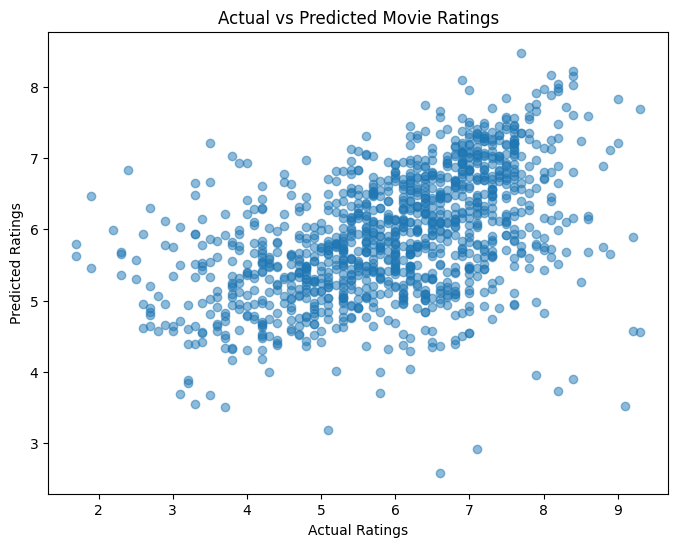

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

In [19]:
import joblib

joblib.dump(model, "movie_rating_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
import os

print("Files in Colab:")
print(os.listdir())

Files in Colab:
['.config', '.ipynb_checkpoints', 'movie_rating_model.pkl', 'IMDb Movies India.csv.csv', 'IMDb Movies India.csv (1).csv', 'movie dataset .zip', 'sample_data']
